# Electricity Load Balancing Game — Demonstration Notebook

This notebook is a **software digital twin** of the hands-on grid game. Use it to
demonstrate the ideas to a class before (or instead of) running the Arduino build.

**The challenge:** keep the grid's electrical **frequency at 50 Hz**. Frequency
is simply a measure of whether *generation* matches *demand*:

- More generation than load  ->  frequency rises above 50 Hz.
- More load than generation  ->  frequency falls below 50 Hz.

A team splits into two roles:
- **Generator players** turn dials to set how much the *hydro* units produce.
- **Network operators** open/close *circuit breakers* to isolate faults and, if
  needed, shed load.

### Learning outcomes
1. Balancing load and generation keeps frequency steady.
2. Generators and network operators each have a distinct job.
3. **Inertia** (from spinning synchronous machines) decides how *fast* frequency
   moves — and wind/solar provide almost none of it.


## 1. Setup and the daily profiles

First the model constants and the load / renewable shapes over a 24-hour day.
Residential demand has a morning and an evening peak; industrial demand is flat;
solar peaks at midday; wind wanders randomly.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

# --- model constants (a presenter can tweak these) ---
NOMINAL_HZ    = 50.0
HYDRO_MAX_MW  = 80.0    # full-scale output of one hydro dial
HYDRO_INERTIA = 4.0     # inertia each online hydro unit contributes
INERTIA_FLOOR = 1.0     # tiny floor so the maths never divides by zero
DAMPING       = 2.0     # load self-regulation, pulls frequency back to 50
FREQ_GAIN     = 0.05    # Hz/s per MW of imbalance per unit of inertia
FAULT_DISTURB = 60.0    # MW the grid "loses" while a fault is live
TRIP_BAND     = 0.8     # |df| beyond this counts as a frequency event
BLACKOUT_BAND = 3.0     # |df| beyond this = collapse
K_FREQ, K_ENERGY, K_EVENT = 4.0, 0.5, 15.0   # scoring weights

def residential_load(h):
    morning = 45 * np.exp(-((h - 8) ** 2) / 4)
    evening = 55 * np.exp(-((h - 19) ** 2) / 6)
    return 55 + morning + evening

def industrial_load(h):
    return 50.0 + 0 * h

def solar_output(h):
    return np.where((h >= 6) & (h <= 18),
                    60 * np.sin(np.pi * (np.clip(h, 6, 18) - 6) / 12), 0.0)


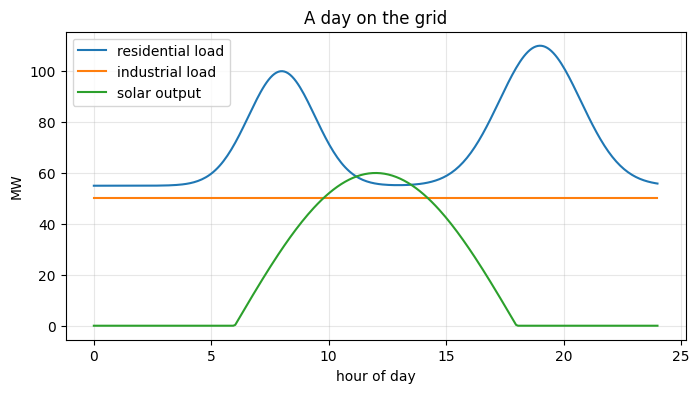

In [2]:
hours = np.linspace(0, 24, 288)
plt.figure(figsize=(8, 4))
plt.plot(hours, residential_load(hours), label="residential load")
plt.plot(hours, industrial_load(hours), label="industrial load")
plt.plot(hours, solar_output(hours), label="solar output")
plt.xlabel("hour of day"); plt.ylabel("MW")
plt.title("A day on the grid"); plt.legend(); plt.grid(alpha=0.3)
plt.show()


## 2. The frequency model (kept deliberately simple)

Each instant, the **imbalance** is generation minus demand. Frequency changes in
proportion to that imbalance, divided by the system **inertia**, plus a damping
term that nudges it back toward 50 Hz:

$$\frac{df}{dt} = \frac{\text{gain}\times\text{imbalance} - \text{damping}\times(f-50)}{\text{inertia}}$$

Only the synchronous **hydro** units add inertia. Wind and solar add power but
**no inertia** — so leaning on them makes frequency swing faster for the same
mistake. That is the inverter-based-resources lesson.


In [3]:
class Sim:
    """One grid. Call step(dt) repeatedly; read .freq and .score()."""
    def __init__(self, minutes=10, seed=0):
        self.rng = random.Random(seed)
        self.game_seconds = minutes * 60
        self.reset()

    def reset(self):
        self.freq = NOMINAL_HZ; self.elapsed = 0.0
        self.hydro1 = HYDRO_MAX_MW * 0.5; self.hydro2 = HYDRO_MAX_MW * 0.5
        self.wind = 25.0
        # B1 = wind+solar, B2 = residential, B3 = industrial, B4 = hydro 2
        self.breakers = {"B1": True, "B2": True, "B3": True, "B4": True}
        self.fault = None; self.fault_clear_at = 0.0; self.next_fault_at = 20.0
        self.fsq = 0.0; self.unserved = 0.0; self.events = 0; self._below = False

    @property
    def hour(self):
        return (self.elapsed / self.game_seconds) * 24 % 24

    def generation(self):
        p = self.hydro1; H = HYDRO_INERTIA
        if self.breakers["B4"]:
            p += self.hydro2; H += HYDRO_INERTIA
        if self.breakers["B1"]:
            p += self.wind + float(solar_output(self.hour))
        return p, max(INERTIA_FLOOR, H)

    def demand(self):
        p = 0.0
        if self.breakers["B2"]: p += float(residential_load(self.hour))
        if self.breakers["B3"]: p += float(industrial_load(self.hour))
        return p

    def _faults(self):
        if self.fault is None and self.elapsed >= self.next_fault_at:
            self.fault = self.rng.choice(list(self.breakers))
            self.fault_clear_at = self.elapsed + self.rng.uniform(8, 15)
        elif self.fault is not None and self.elapsed >= self.fault_clear_at:
            self.fault = None
            self.next_fault_at = self.elapsed + self.rng.uniform(25, 50)

    def step(self, dt):
        self.elapsed += dt
        self.wind = min(50, max(0, self.wind + self.rng.uniform(-1, 1) * dt * 8))
        self._faults()
        pG, H = self.generation(); pL = self.demand()
        dist = FAULT_DISTURB if (self.fault and self.breakers[self.fault]) else 0.0
        imb = pG - pL - dist
        rocof = (FREQ_GAIN * imb - DAMPING * (self.freq - NOMINAL_HZ)) / H
        self.freq += rocof * dt
        self._score(dt)
        return pG, pL, H, imb

    def _score(self, dt):
        df = self.freq - NOMINAL_HZ; self.fsq += df * df * dt
        shed = 0.0
        if not self.breakers["B2"]: shed += float(residential_load(self.hour))
        if not self.breakers["B3"]: shed += float(industrial_load(self.hour))
        self.unserved += shed * dt / 3600
        out = abs(df) > TRIP_BAND
        if out and not self._below: self.events += 1
        self._below = out
        if abs(df) > BLACKOUT_BAND:
            self.events += 2; self.freq = NOMINAL_HZ

    def score(self):
        raw = 1000 - K_FREQ * self.fsq - K_ENERGY * self.unserved - K_EVENT * self.events
        return max(0, round(raw))


def auto_control(sim):
    """A competent 'team': isolate faults, chase the load with hydro."""
    for b in sim.breakers:
        if sim.fault == b:
            sim.breakers[b] = False
        elif not sim.breakers[b] and sim.fault is None:
            sim.breakers[b] = True
    pG, _ = sim.generation(); pL = sim.demand(); err = pL - pG
    sim.hydro1 = min(HYDRO_MAX_MW, max(0, sim.hydro1 + err * 0.5))
    if sim.breakers["B4"]:
        sim.hydro2 = min(HYDRO_MAX_MW, max(0, sim.hydro2 + err * 0.5))


def run_game(control=None, minutes=10, seed=0, dt=0.1):
    sim = Sim(minutes, seed)
    t, f, g, l, faults = [], [], [], [], []
    while sim.elapsed < sim.game_seconds:
        if control: control(sim)
        pG, pL, H, imb = sim.step(dt)
        t.append(sim.hour); f.append(sim.freq); g.append(pG); l.append(pL)
        if sim.fault: faults.append(sim.hour)
    return dict(t=t, f=f, g=g, l=l, faults=faults, score=sim.score(),
                unserved=round(sim.unserved, 2), events=sim.events)


## 3. Demo 1 — watch a day unfold

Here a competent team (the auto-controller) keeps generation chasing the load and
isolates each fault as it appears. Watch how tightly frequency hugs 50 Hz.


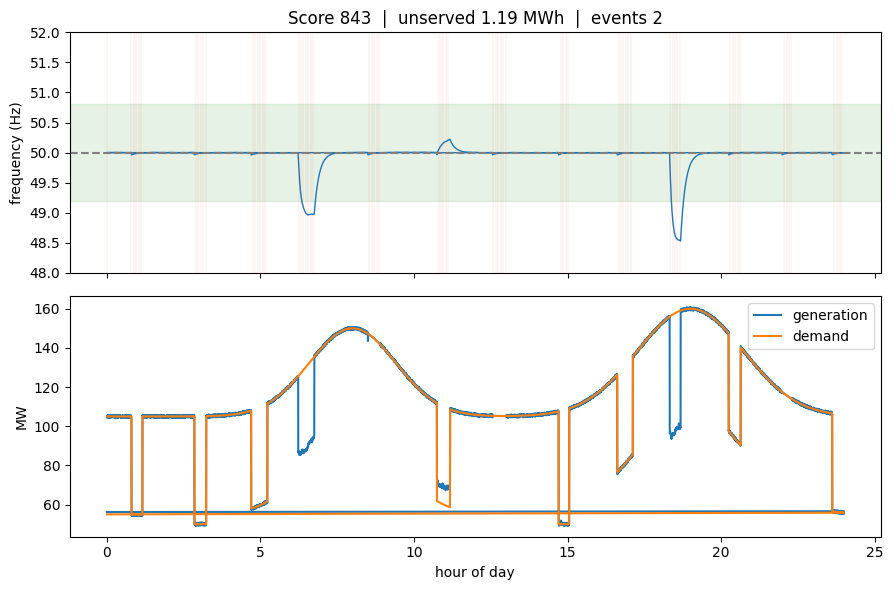

In [4]:
r = run_game(auto_control, minutes=10, seed=3)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax1.plot(r["t"], r["f"], lw=1)
ax1.axhline(50, ls="--", c="gray")
ax1.axhspan(50 - TRIP_BAND, 50 + TRIP_BAND, alpha=0.1, color="green")
for fh in r["faults"][::20]:
    ax1.axvline(fh, color="red", alpha=0.04)
ax1.set_ylabel("frequency (Hz)"); ax1.set_ylim(48, 52)
ax1.set_title(f"Score {r['score']}  |  unserved {r['unserved']} MWh  |  events {r['events']}")

ax2.plot(r["t"], r["g"], label="generation")
ax2.plot(r["t"], r["l"], label="demand")
ax2.set_xlabel("hour of day"); ax2.set_ylabel("MW"); ax2.legend()
plt.tight_layout(); plt.show()


## 4. Demo 2 — skilled team vs hands-off

Same day, same faults. The only difference is whether anyone is steering.


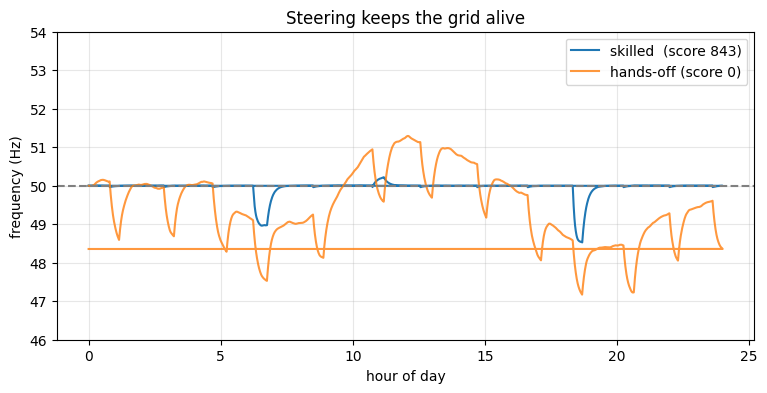

Skilled : 843 | Hands-off: 0


In [5]:
skilled = run_game(auto_control, minutes=10, seed=3)
idle    = run_game(None,          minutes=10, seed=3)

plt.figure(figsize=(9, 4))
plt.plot(skilled["t"], skilled["f"], label=f"skilled  (score {skilled['score']})")
plt.plot(idle["t"],    idle["f"],    label=f"hands-off (score {idle['score']})", alpha=0.8)
plt.axhline(50, ls="--", c="gray")
plt.xlabel("hour of day"); plt.ylabel("frequency (Hz)"); plt.ylim(46, 54)
plt.title("Steering keeps the grid alive"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

print("Skilled :", skilled["score"], "| Hands-off:", idle["score"])


## 5. Demo 3 — why inertia matters

Now the key lesson. Hit the grid with the *same* sudden 20 MW generation shortfall,
but with different amounts of synchronous (hydro) inertia online. Less inertia =
faster, deeper frequency drop — even though the disturbance is identical. This is
what happens as wind and solar (which add no inertia) displace spinning machines.


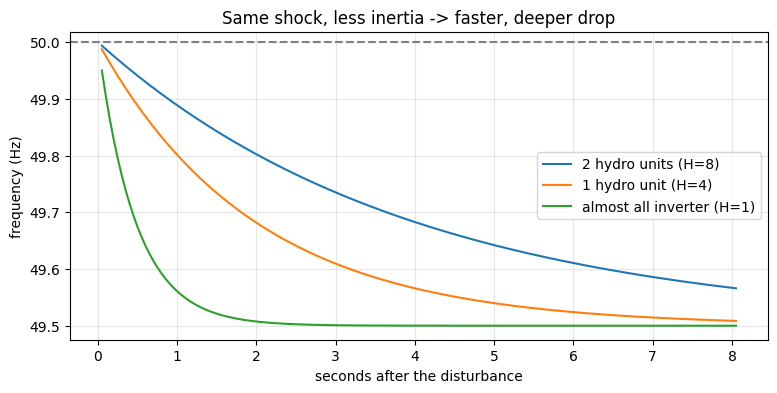

In [6]:
def freq_response(inertia, imbalance=-20.0, T=8.0, dt=0.05):
    f, t, ts, fs = NOMINAL_HZ, 0.0, [], []
    while t < T:
        rocof = (FREQ_GAIN * imbalance - DAMPING * (f - NOMINAL_HZ)) / inertia
        f += rocof * dt; t += dt; ts.append(t); fs.append(f)
    return ts, fs

plt.figure(figsize=(9, 4))
for label, H in [("2 hydro units (H=8)", 8.0),
                 ("1 hydro unit (H=4)", 4.0),
                 ("almost all inverter (H=1)", 1.0)]:
    ts, fs = freq_response(H)
    plt.plot(ts, fs, label=label)
plt.axhline(50, ls="--", c="gray")
plt.xlabel("seconds after the disturbance"); plt.ylabel("frequency (Hz)")
plt.title("Same shock, less inertia -> faster, deeper drop")
plt.legend(); plt.grid(alpha=0.3); plt.show()


## 6. Play with it live

Drag the sliders to set hydro output, the load, and how many synchronous units
are online, and watch where frequency settles and how fast it gets there.

A nice thing to point out: **inertia changes how *fast* frequency moves, while the
balance and damping set *where* it settles.** (Requires `ipywidgets`; if it isn't
installed, a static example is shown instead.)


In [7]:
def show_response(hydro_MW=120, load_MW=130, synchronous_units=2):
    H = max(INERTIA_FLOOR, HYDRO_INERTIA * synchronous_units)
    imb = hydro_MW - load_MW
    f, t, ts, fs = NOMINAL_HZ, 0.0, [], []
    while t < 10:
        rocof = (FREQ_GAIN * imb - DAMPING * (f - NOMINAL_HZ)) / H
        f += rocof * 0.05; t += 0.05; ts.append(t); fs.append(f)
    plt.figure(figsize=(8, 3.5))
    plt.axhline(50, ls="--", c="gray")
    plt.axhspan(50 - TRIP_BAND, 50 + TRIP_BAND, alpha=0.1, color="green")
    plt.plot(ts, fs)
    plt.ylim(45, 55); plt.xlabel("seconds"); plt.ylabel("Hz")
    plt.title(f"imbalance {imb:+d} MW, inertia H={H:.0f}  ->  settles near {fs[-1]:.2f} Hz")
    plt.show()

try:
    import ipywidgets as widgets
    widgets.interact(
        show_response,
        hydro_MW=widgets.IntSlider(min=0, max=200, value=120, step=5),
        load_MW=widgets.IntSlider(min=0, max=200, value=130, step=5),
        synchronous_units=widgets.IntSlider(min=0, max=2, value=2),
    )
except ImportError:
    print("ipywidgets not installed - static example below:")
    show_response()


interactive(children=(IntSlider(value=120, description='hydro_MW', max=200, step=5), IntSlider(value=130, desc…

## 7. From notebook to hardware

This is the same model that runs on the Arduino build of the game
(`load_balancing_game.ino`). There the two hydro dials are potentiometers, the
breakers are switches with status LEDs, and a servo physically tracks the
frequency. Use this notebook to teach the ideas, then let teams play it for real.
